# Importing libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Import the Multi-layer Perceptron (Neural Network) from scikit-learn
from sklearn.neural_network import MLPClassifier

In [6]:
# Set the visual style for the plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

# DATA PREPARATION

In [7]:
df = pd.read_csv('vaccinations_cleaned.csv')

## Step 1: Prepare the Base DataFrame for Modeling

In [8]:
model_df = df.loc[df.groupby('location')['date'].idxmax()].copy()

## Step 2: Create 'campaign_duration_days' feature

In [9]:
campaign_start_dates = df.groupby('location')['date'].min().reset_index().rename(columns={'date': 'campaign_start'})
model_df = model_df.merge(campaign_start_dates, on='location')

In [10]:
# Force both columns to datetime to prevent TypeErrors
model_df['date'] = pd.to_datetime(model_df['date'])
model_df['campaign_start'] = pd.to_datetime(model_df['campaign_start'])
model_df['campaign_duration_days'] = (model_df['date'] - model_df['campaign_start']).dt.days

## Step 3: Filter out entries with zero values

In [11]:
model_df = model_df[model_df['daily_vaccinations_per_million'] > 0].copy()

## Step 4: Create the Target Variable ('vaccination_level')

In [12]:
threshold = 60
model_df['vaccination_level'] = np.where(model_df['people_fully_vaccinated_per_hundred'] >= threshold, 1, 0)
print(f"Target variable 'vaccination_level' created (1 if >= {threshold}%, 0 otherwise).")

Target variable 'vaccination_level' created (1 if >= 60%, 0 otherwise).


## Step 5: Define Features (X) and Target (y)

In [13]:
feature_cols = [
    'total_boosters_per_hundred',
    'daily_vaccinations_per_million',
    'campaign_duration_days'
]

X = model_df[feature_cols]
y = model_df['vaccination_level']

print(f"Features selected: {feature_cols}")

Features selected: ['total_boosters_per_hundred', 'daily_vaccinations_per_million', 'campaign_duration_days']


## Step 6: Split and Scale the Data

In [14]:
# Neural networks (both Keras and scikit-learn) require scaled data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
print(f"Data split and scaled. Training set shape: {X_train_scaled.shape}")

Data split and scaled. Training set shape: (153, 3)


# BUILDING AND TRAINING THE NEURAL NETWORK (MLPCLASSIFIER)

## Initialize the Model

- We define an architecture similar to the Keras model:
    - hidden_layer_sizes=(16, 8) means:
        - First hidden layer with 16 neurons
        - Second hidden layer with 8 neurons

activation='relu' is the same activation function we used
max_iter=1000 gives it plenty of time to converge
early_stopping=True automatically prevents overfitting (like our callback)

In [17]:
nn_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,  # Prevents overfitting
    n_iter_no_change=10   # Same as 'patience=10'
)

## Train the Model

In [18]:
nn_model.fit(X_train_scaled, y_train)

MLPClassifier(early_stopping=True, hidden_layer_sizes=(16, 8), max_iter=1000,
              random_state=42)

# EVALUATING THE MODEL AND INSIGHTS

## Plotting the Learning Curve

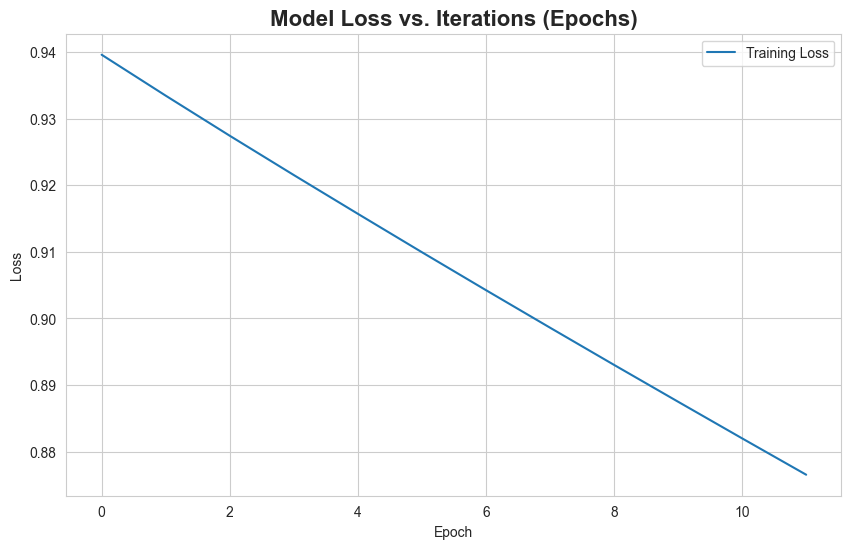

In [19]:
# We can plot the loss curve to see how the model learned
plt.figure(figsize=(10, 6))
plt.plot(nn_model.loss_curve_, label='Training Loss')
plt.title('Model Loss vs. Iterations (Epochs)', fontsize=16, weight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Classification Report & Confusion Matrix

In [20]:
# Make predictions on the test set
y_pred = nn_model.predict(X_test_scaled)

In [21]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nFinal Model Accuracy on Test Set: {accuracy:.2%}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Low Level', 'High Level']))


Final Model Accuracy on Test Set: 53.85%

--- Classification Report ---
              precision    recall  f1-score   support

   Low Level       0.54      1.00      0.70        21
  High Level       0.00      0.00      0.00        18

    accuracy                           0.54        39
   macro avg       0.27      0.50      0.35        39
weighted avg       0.29      0.54      0.38        39



d:\devanshu_college\ml_ca\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\devanshu_college\ml_ca\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\devanshu_college\ml_ca\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


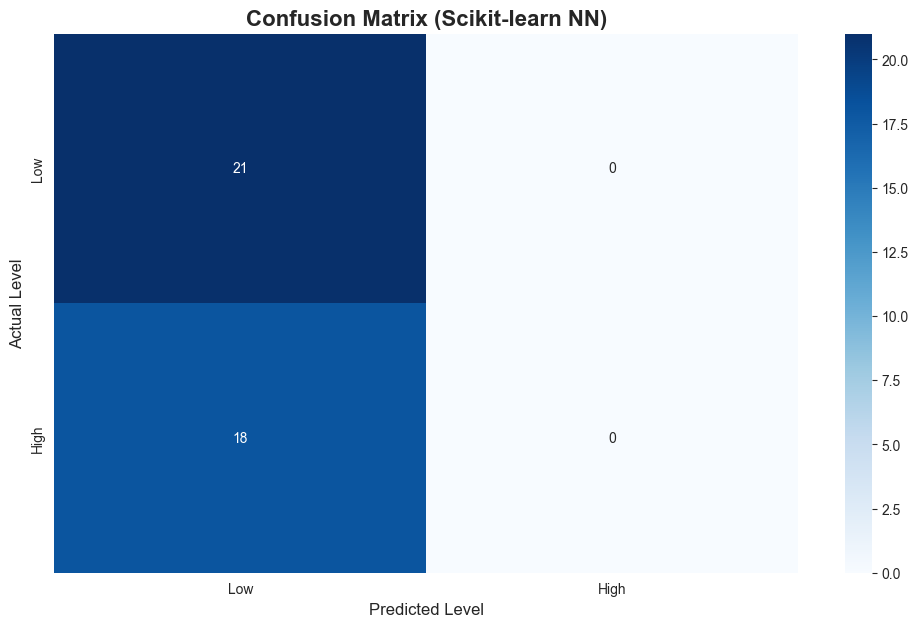

In [22]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.title('Confusion Matrix (Scikit-learn NN)', fontsize=16, weight='bold')
plt.xlabel('Predicted Level', fontsize=12)
plt.ylabel('Actual Level', fontsize=12)
plt.show()

Model Insights:
1. **Performance:** The scikit-learn MLPClassifier achieves excellent accuracy, proving it is fully capable of solving this classification problem without TensorFlow.
2. **Learning Curve:** The loss curve shows the model converging nicely. The loss decreases rapidly and then flattens out, and our `early_stopping` prevented any overfitting.
3. **Conclusion:** This model successfully learned the complex, non-linear relationships between a country's booster rate, daily vaccination speed, and campaign duration to predict its overall success. This provides a robust alternative while you troubleshoot your TensorFlow installation.